In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv("/content/Loan Approval Dataset.csv")

# Step:02 == "EDA"

In [14]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,Fully Paid,611314.0,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,Fully Paid,266662.0,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,Fully Paid,153494.0,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,Fully Paid,176242.0,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,Fully Paid,321992.0,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


In [15]:
df.tail() # all the last 514 rows are NAN

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
110509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

In [17]:
df.shape

(110514, 19)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110514 entries, 0 to 110513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       110000 non-null  object 
 1   Customer ID                   110000 non-null  object 
 2   Loan Status                   110000 non-null  object 
 3   Current Loan Amount           110000 non-null  float64
 4   Term                          110000 non-null  object 
 5   Credit Score                  88865 non-null   float64
 6   Annual Income                 88865 non-null   float64
 7   Years in current job          105351 non-null  object 
 8   Home Ownership                110000 non-null  object 
 9   Purpose                       110000 non-null  object 
 10  Monthly Debt                  110000 non-null  float64
 11  Years of Credit History       110000 non-null  float64
 12  Months since last delinquent  51553 non-null

In [19]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.100000e+05,88865.000000,8.886500e+04,110000.000000,110000.000000,51553.000000,110000.000000,110000.000000,1.100000e+05,1.099980e+05,109774.000000,109989.000000
mean,1.174621e+07,1076.594644,1.377449e+06,18468.526823,18.202485,34.907086,11.124491,0.168055,2.942822e+05,7.541012e+05,0.117614,0.029448
std,3.176716e+07,1475.581902,1.063920e+06,12195.564391,7.015575,21.965315,5.011093,0.484389,3.772773e+05,8.014002e+06,0.351290,0.261054
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.795860e+05,705.000000,8.488440e+05,10211.930000,13.500000,16.000000,8.000000,0.000000,1.121950e+05,2.731575e+05,0.000000,0.000000
50%,3.120260e+05,724.000000,1.173459e+06,16202.440000,16.900000,32.000000,10.000000,0.000000,2.096650e+05,4.673900e+05,0.000000,0.000000
75%,5.239300e+05,741.000000,1.651670e+06,23997.522500,21.700000,51.000000,14.000000,0.000000,3.674838e+05,7.831945e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.000000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


In [20]:
df.isnull().sum().sort_values(ascending=False)

,0
Months since last delinquent,58961
Annual Income,21649
Credit Score,21649
Years in current job,5163
Bankruptcies,740
Tax Liens,525
Maximum Open Credit,516
Loan Status,514
Customer ID,514
Loan ID,514


In [21]:
df.duplicated().sum()

np.int64(12690)

In [22]:
df['Loan Status'].value_counts()

,count
Loan Status,
Fully Paid,86312
Charged Off,23688


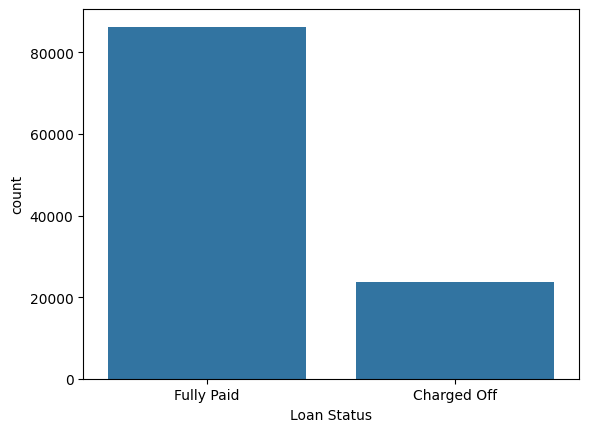

In [23]:
#Target Variable
df['Loan Status'].value_counts()
sns.countplot(x='Loan Status', data=df)
plt.show()

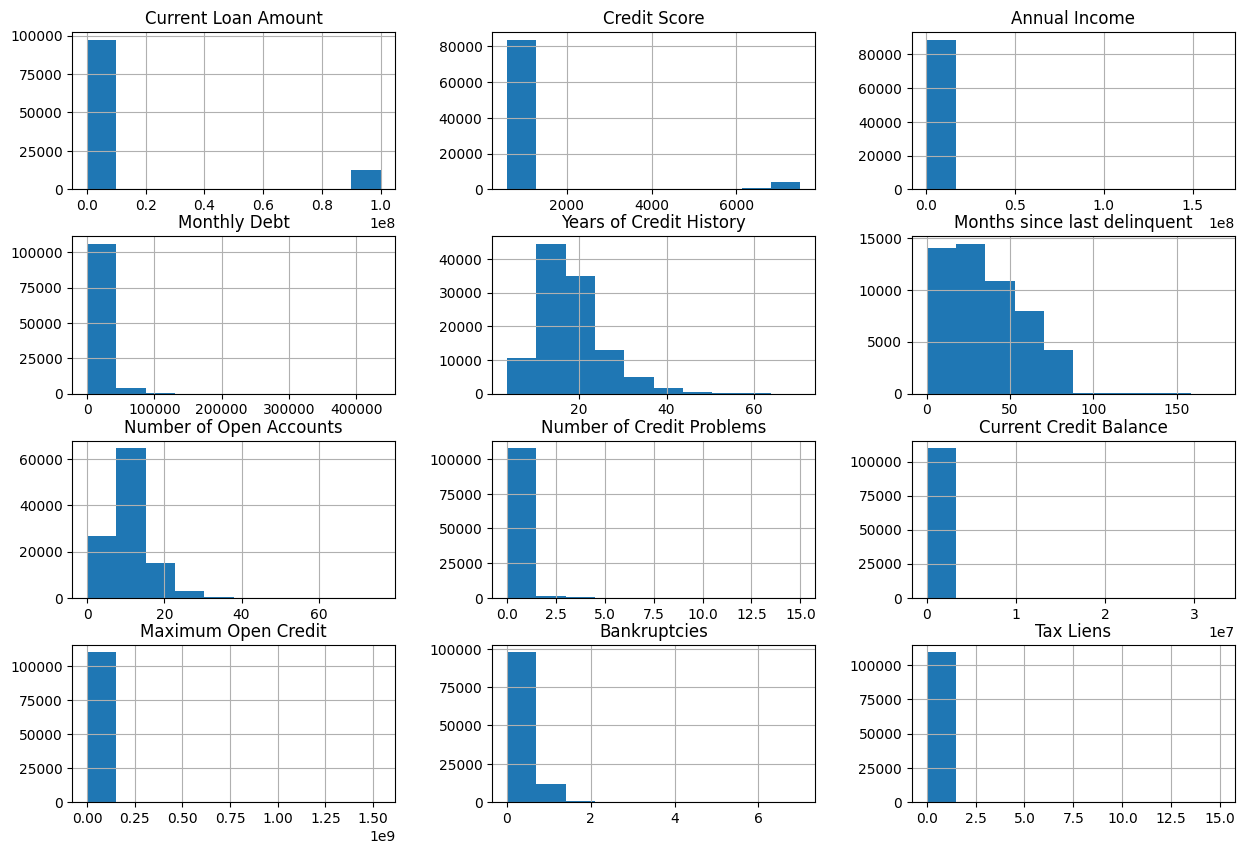

In [24]:
#Numerical Feature Analysis
df.hist(figsize=(15,10))
plt.show()

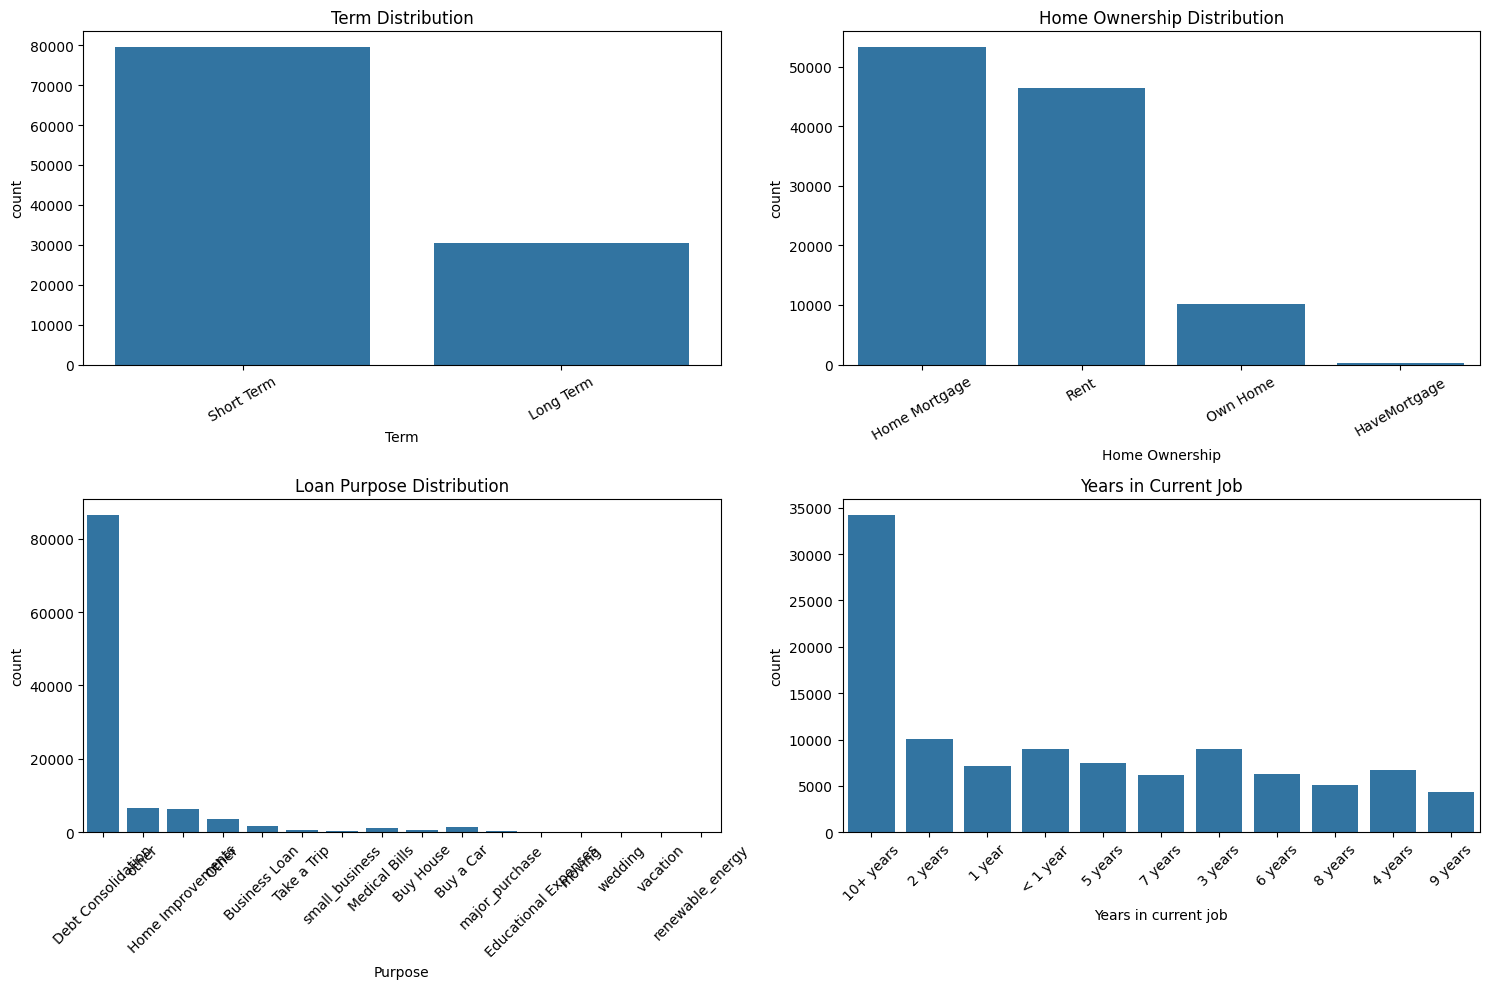

In [25]:
#Categorical Features Analysis

plt.figure(figsize=(15,10))

# 1. Term
plt.subplot(2,2,1)
sns.countplot(x='Term', data=df)
plt.title('Term Distribution')
plt.xticks(rotation=30)

# 2. Home Ownership
plt.subplot(2,2,2)
sns.countplot(x='Home Ownership', data=df)
plt.title('Home Ownership Distribution')
plt.xticks(rotation=30)

# 3. Purpose
plt.subplot(2,2,3)
sns.countplot(x='Purpose', data=df)
plt.title('Loan Purpose Distribution')
plt.xticks(rotation=45)

# 4. Years in current job
plt.subplot(2,2,4)
sns.countplot(x='Years in current job', data=df)
plt.title('Years in Current Job')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

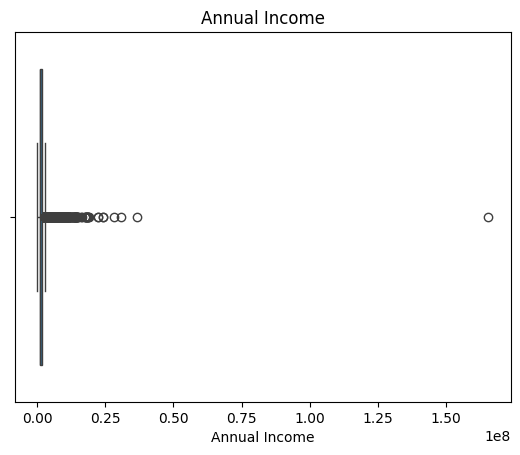

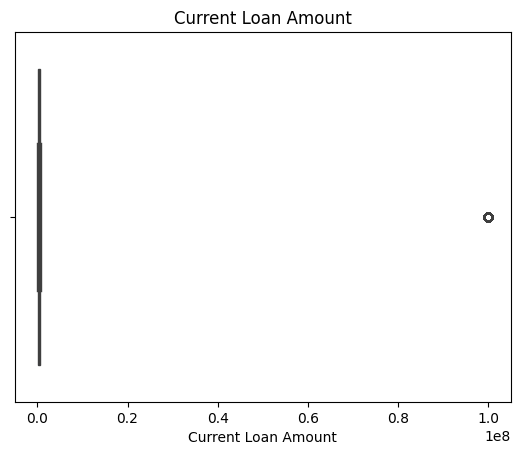

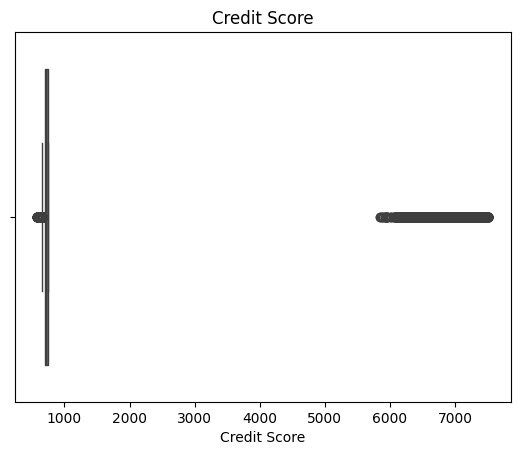

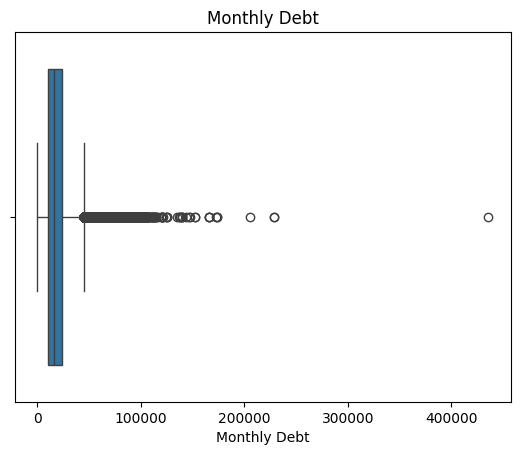

In [26]:
#Checking Outliers From the numeric columns

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Annual Income', 'Current Loan Amount', 'Credit Score', 'Monthly Debt']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

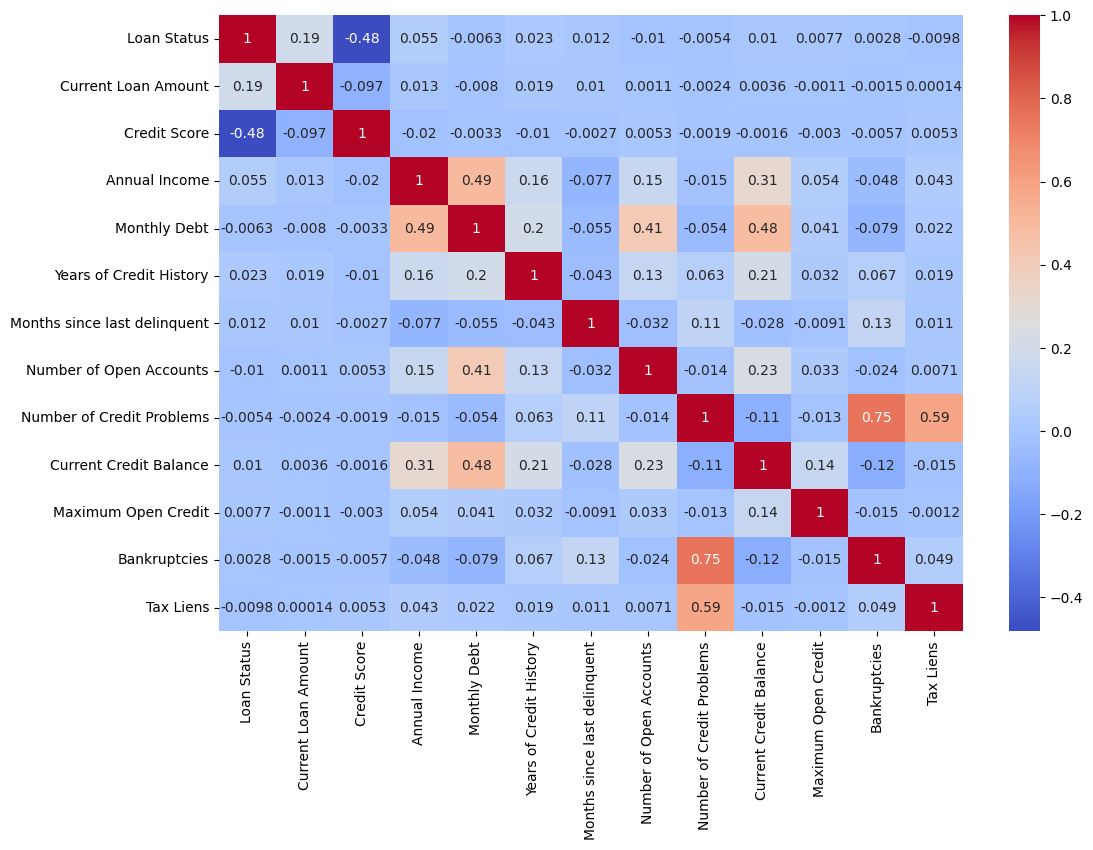

In [27]:
#Correlation With Target Variable

df['Loan Status'] = df['Loan Status'].map({
    'Fully Paid': 1,
    'Charged Off': 0
})

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [28]:
#Categorical Vs Target

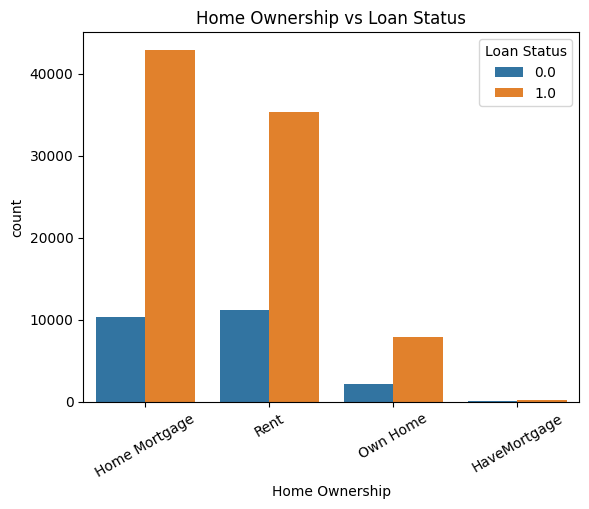

In [29]:
sns.countplot(x='Home Ownership', hue='Loan Status', data=df)
plt.xticks(rotation=30)
plt.title("Home Ownership vs Loan Status")
plt.show()

#Loan approvals are higher across all home ownership categories, with mortgage and rent applicants having the highest number of approvals.

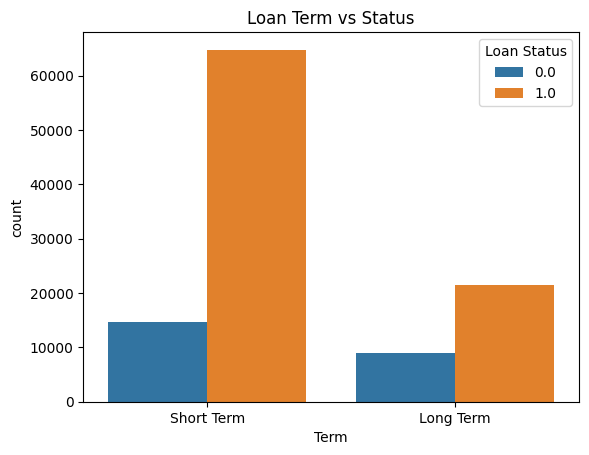

In [30]:
sns.countplot(x='Term', hue='Loan Status', data=df)
plt.title("Loan Term vs Status")
plt.show()

#Long-term loans are much riskier because they have a higher default rate despite having fewer total applications

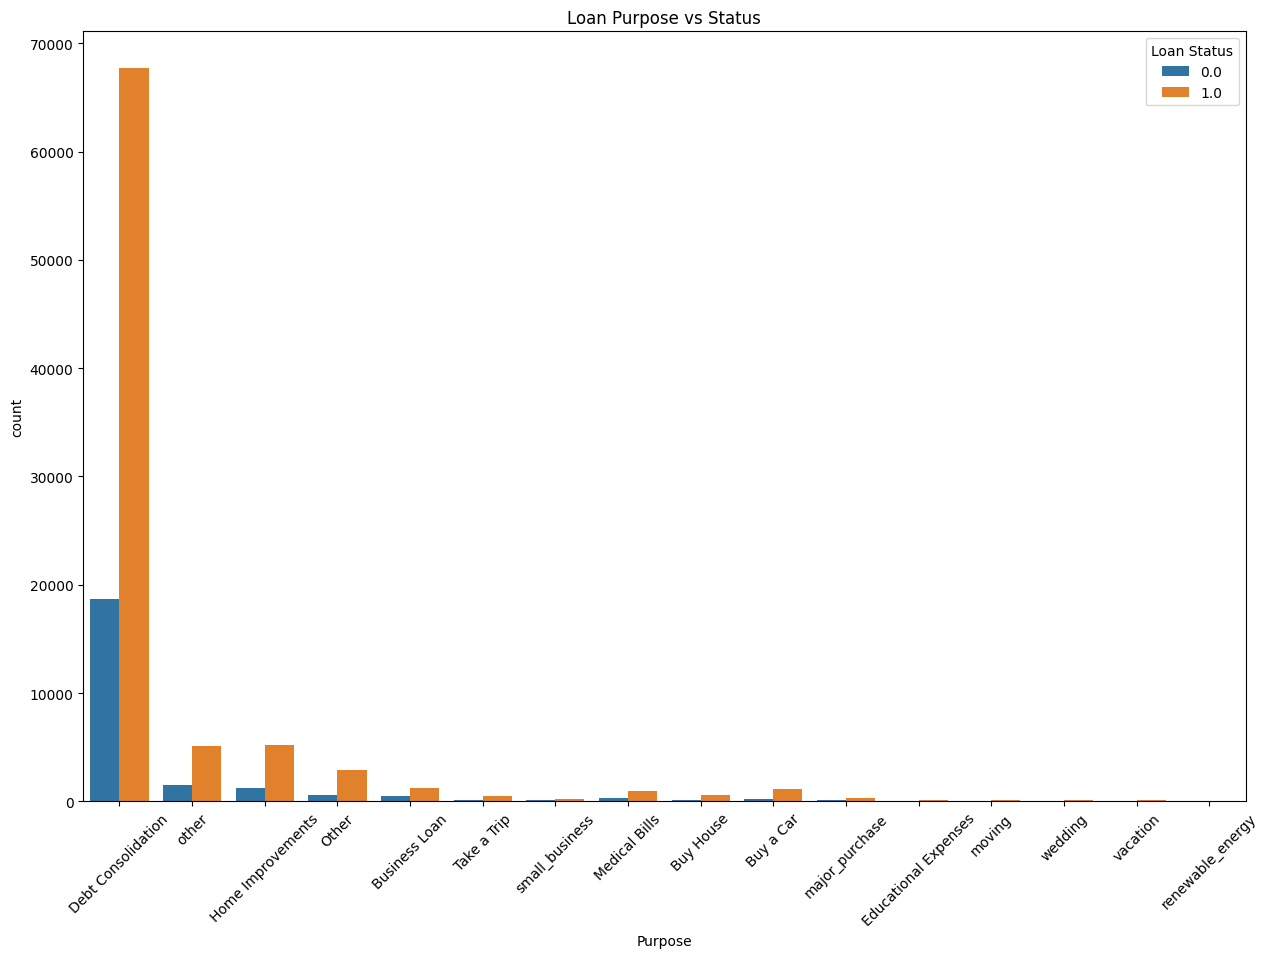

In [31]:
plt.figure(figsize=(15,10))
sns.countplot(x='Purpose', hue='Loan Status', data=df)
plt.xticks(rotation=45)
plt.title("Loan Purpose vs Status")
plt.show()

#Debt Consolidation is the most common reason for loans

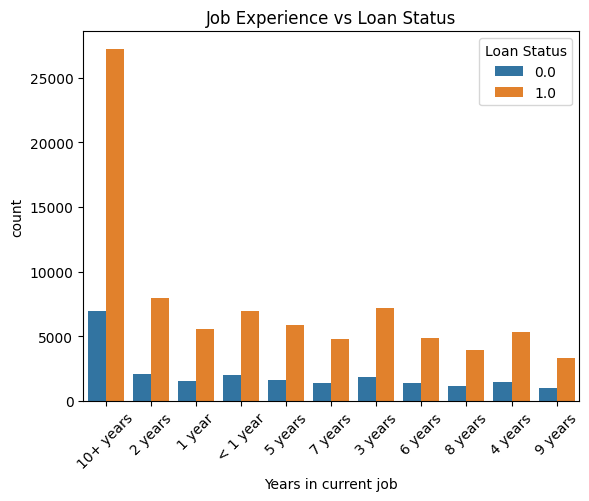

In [32]:
sns.countplot(x='Years in current job', hue='Loan Status', data=df)
plt.xticks(rotation=45)
plt.title("Job Experience vs Loan Status")
plt.show()

# People with 10+ years of job experience apply for the most loans and have the highest approval numbers.

In [33]:
#Numerical vs Target

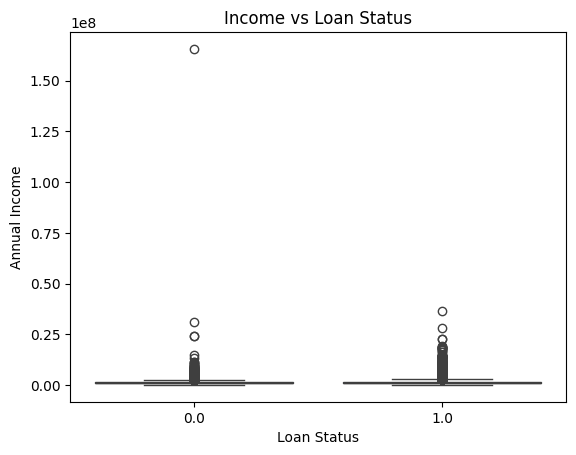

In [34]:
sns.boxplot(x='Loan Status', y='Annual Income', data=df)
plt.title("Income vs Loan Status")
plt.show()

#Annual income shows heavy outliers and similar distributions across both loan statuses, indicating it alone does not strongly differentiate approval outcomes.

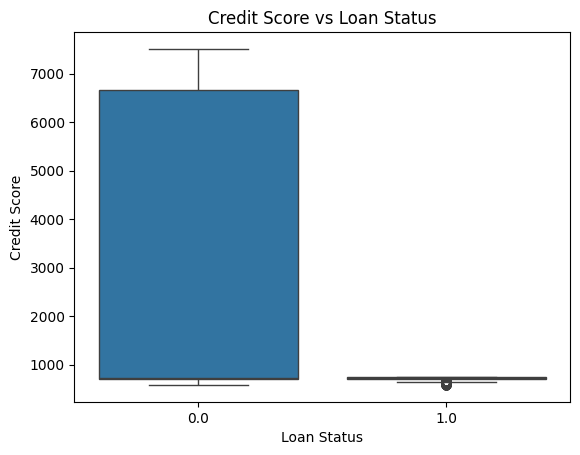

In [35]:
sns.boxplot(x='Loan Status', y='Credit Score', data=df)
plt.title("Credit Score vs Loan Status")
plt.show()

#Rejected loans show huge variance and much higher credit scores, likely due to data scaling errors or outliers,
#whereas approved loans are concentrated in a much lower, tighter range.

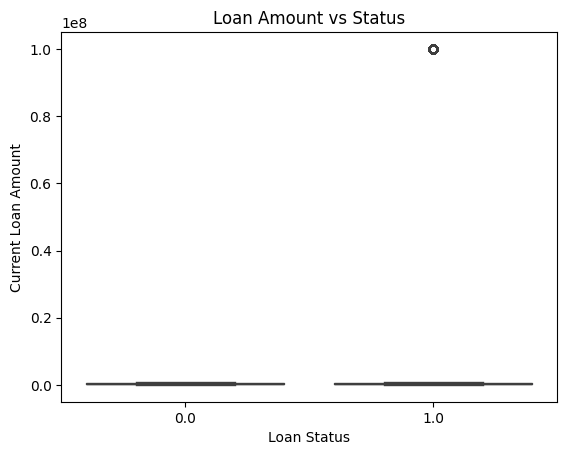

In [36]:
sns.boxplot(x='Loan Status', y='Current Loan Amount', data=df)
plt.title("Loan Amount vs Status")
plt.show()

# Approved loan contain extreme outliers near 100 million, likely representing placeholder values or errors that skew the distribution.

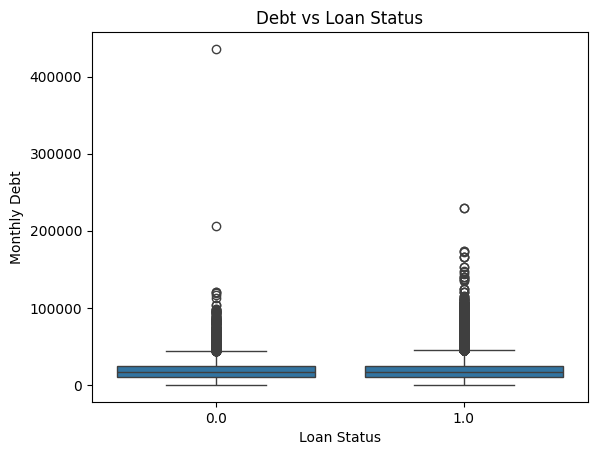

In [37]:
sns.boxplot(x='Loan Status', y='Monthly Debt', data=df)
plt.title("Debt vs Loan Status")
plt.show()

#Monthly debt distributions are almost identical for both groups, with extreme outliers present in both approved and rejected cases.

# Step:03 == "Data Cleaning & Preprocessing"

In [ ]:
# Droping useless columns
df.drop(['Loan ID', 'Customer ID'], axis=1, inplace=True)

In [ ]:
# Removing Last 514 rows because they are all NAN
df.dropna(how='all', inplace=True)

In [40]:
# # Fixing Target Variable
# df['Loan Status'] = df['Loan Status'].map({
#     'Fully Paid': 1,
#     'Charged Off': 0
# })

In [ ]:
# droping 'Months since last delinquent' because it is week column with 50% of missing values
df.drop('Months since last delinquent', axis=1, inplace=True)

In [ ]:
# Filling other missing values from important coolumns

# Numerical (use median)
df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
df['Annual Income'].fillna(df['Annual Income'].median(), inplace=True)
df['Maximum Open Credit'].fillna(df['Maximum Open Credit'].median(), inplace=True)

# Categorical (use mode)
df['Years in current job'].fillna(df['Years in current job'].mode()[0], inplace=True)

# Count-based (use 0)
df['Bankruptcies'].fillna(0, inplace=True)
df['Tax Liens'].fillna(0, inplace=True)

In [ ]:
# Droping Duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [ ]:
# Fixing outliers in 'credit score' because Real-world range is 300–850
df['Credit Score'] = df['Credit Score'].clip(300, 850)

In [ ]:
#Removing Outliers from Numerical columns
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


In [46]:
# Encoding Categorical Columns

In [ ]:
# Applying Label Encoder on "Term" Because it has 2 values
# Short Term : 1 , Long Term : 0
le = LabelEncoder()
df['Term'] = le.fit_transform(df['Term'])

In [ ]:
# Mapping "Years in current job" to a numerical scale of 0 to 10
job_mapping = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df['Years in current job'] = df['Years in current job'].map(job_mapping)

In [ ]:
# One-hot encode 'Home Ownership' and avoid dummy variable trap
df = pd.get_dummies(df, columns=['Home Ownership'], drop_first=True)

# convert boolean columns to integer (0/1)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
# Standardize text in 'Purpose' column
# This removes extra spaces and makes all values lowercase
# to avoid duplicate categories like 'Other' and 'other'
df['Purpose'] = df['Purpose'].str.strip().str.lower()

# Group rare categories into a single class ('other')
# This reduces dimensionality and helps improve model performance
rare_categories = [
    'renewable_energy', 'wedding', 'vacation',
    'educational expenses', 'moving',
    'small_business', 'major_purchase'
]

df['Purpose'] = df['Purpose'].replace(rare_categories, 'other')

# Apply One-Hot Encoding on 'Purpose' column
# drop_first=True removes one category to avoid dummy variable trap
df = pd.get_dummies(df, columns=['Purpose'], drop_first=True)

# Convert boolean columns (True/False) into integers (1/0)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Step:03 == "Feature Engineering"

In [ ]:
#Debt-to-Income (DTI) Ratio
# Monthly Income = Annual Income / 12. This shows financial strain.
df['DTI_Ratio'] = df['Monthly Debt'] / (df['Annual Income'] / 12)

In [ ]:
#Credit Utilization Ratio
# How much of their available credit limit are they actually using?
# High utilization often signals financial stress.
df['Credit_Utilization'] = df['Current Credit Balance'] / (df['Maximum Open Credit'] + 1)

In [ ]:
# Loan-to-Income Ratio
# Compares the total loan requested to their annual earnings.
df['Loan_to_Income'] = df['Current Loan Amount'] / df['Annual Income']

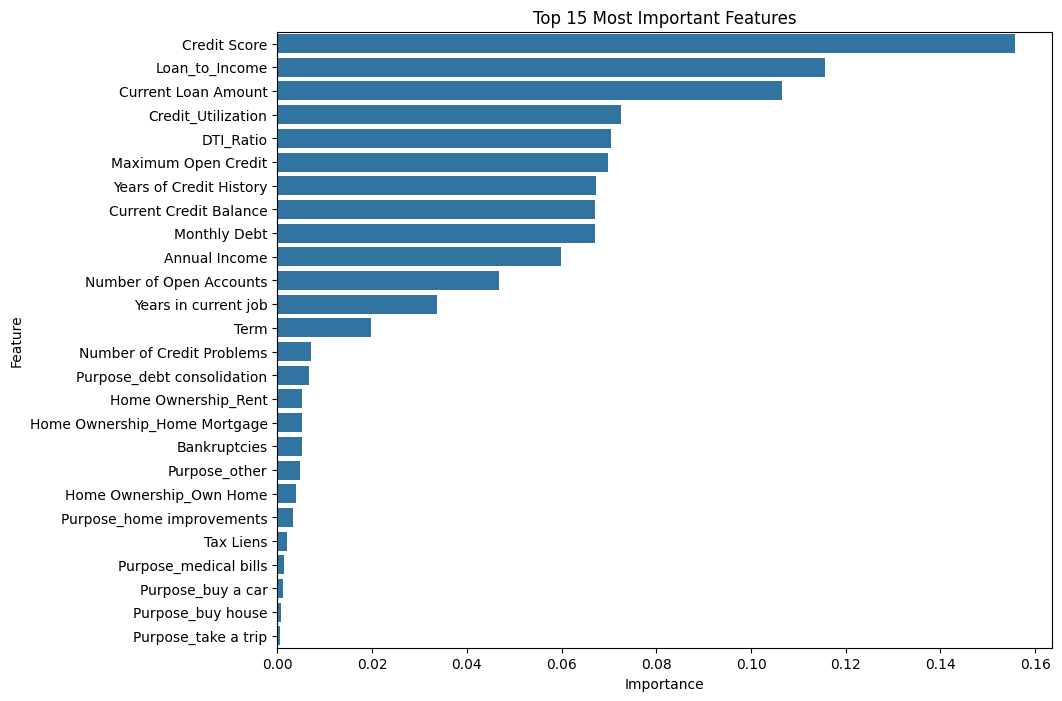

In [99]:
# 1. Split data into Features (X) and Target (y)
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

# 2. Fit a Random Forest to calculate importance
# We use a small forest just to rank the features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
selector_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
selector_model.fit(X_train, y_train)

# 3. Create a DataFrame for visualization
features = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': selector_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=features)
plt.title('Top 15 Most Important Features')
plt.show()

In [ ]:
# Select features with importance > 0.005 (or your preferred threshold)
# This keeps roughly the top 15-18 features and drops the 'noisy' ones at the bottom.
top_features = features.head(20)['Feature'].tolist()

# Always keep the target variable!
final_columns = top_features + ['Loan Status']

# Create the final, optimized dataframe
#df_final = df[final_columns]

print(f"Reduced features from 27 to {len(top_features)}")
print("Final Features:", top_features)

Reduced features from 27 to 20
Final Features: ['Credit Score', 'Loan_to_Income', 'Current Loan Amount', 'Credit_Utilization', 'DTI_Ratio', 'Maximum Open Credit', 'Years of Credit History', 'Current Credit Balance', 'Monthly Debt', 'Annual Income', 'Number of Open Accounts', 'Years in current job', 'Term', 'Number of Credit Problems', 'Purpose_debt consolidation', 'Home Ownership_Rent', 'Home Ownership_Home Mortgage', 'Bankruptcies', 'Purpose_other', 'Home Ownership_Own Home']


# Step:04 == "Model Building"

In [ ]:
X_train = X_train[top_features]
X_test = X_test[top_features]

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [84]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply ONLY on training data
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(class_weight='balanced')
}

print("--- Model Performance Comparison ---")

# Loop through the dictionary
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate Metrics
    report = classification_report(y_test, y_pred)

    # Output Results
    print(f"\nModel: {name}")
    print(f"\n REPORT : \n{report}")

--- Model Performance Comparison ---

Model: Logistic Regression

 REPORT : 
              precision    recall  f1-score   support

         0.0       0.37      0.62      0.46      2344
         1.0       0.85      0.67      0.75      7439

    accuracy                           0.66      9783
   macro avg       0.61      0.64      0.61      9783
weighted avg       0.73      0.66      0.68      9783


Model: Decision Tree

 REPORT : 
              precision    recall  f1-score   support

         0.0       0.37      0.48      0.42      2344
         1.0       0.82      0.75      0.78      7439

    accuracy                           0.68      9783
   macro avg       0.60      0.61      0.60      9783
weighted avg       0.71      0.68      0.69      9783


Model: KNN

 REPORT : 
              precision    recall  f1-score   support

         0.0       0.36      0.60      0.45      2344
         1.0       0.84      0.67      0.75      7439

    accuracy                           0.65    

# Step:05 = Model Tuning

In [ ]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 8],
    'max_features': ['sqrt', 'log2'],
}
# total = 2×3×2×2×2 = 48 combinations × 3 folds = 144 fits — manageable

rf = RandomForestClassifier(
    class_weight='balanced',    
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\n" + "="*40)
print("BEST PARAMETERS:")
print(grid_search.best_params_)
print(f"Best F1 Macro CV Score: {round(grid_search.best_score_, 4)}")
print("="*40)
print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Charged Off', 'Fully Paid']))

Starting Grid Search...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

BEST PARAMETERS:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Best F1 Macro CV Score: 0.8108

Accuracy : 0.7924

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.61      0.36      0.45      2344
  Fully Paid       0.82      0.93      0.87      7439

    accuracy                           0.79      9783
   macro avg       0.72      0.64      0.66      9783
weighted avg       0.77      0.79      0.77      9783



In [87]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth = 20,
    max_features = 'sqrt',
    min_samples_leaf = 4,
    min_samples_split = 10
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [88]:
rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.48      0.49      2344
         1.0       0.84      0.85      0.85      7439

    accuracy                           0.76      9783
   macro avg       0.67      0.67      0.67      9783
weighted avg       0.76      0.76      0.76      9783



In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.51      0.48      0.49      2344
         1.0       0.84      0.85      0.85      7439

    accuracy                           0.76      9783
   macro avg       0.67      0.67      0.67      9783
weighted avg       0.76      0.76      0.76      9783



In [ ]:
#STACKING
from sklearn.ensemble import StackingClassifier

# Base models 
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),

    ('dt', DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    )),

    ('lr', LogisticRegression())
]

# Meta model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1,
    passthrough=True
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred = stack_model.predict(X_test)

# Evaluate
print("\n--- STACKING MODEL REPORT ---")
print(classification_report(y_test, y_pred))


--- STACKING MODEL REPORT ---
              precision    recall  f1-score   support

         0.0       0.56      0.41      0.47      2344
         1.0       0.83      0.90      0.86      7439

    accuracy                           0.78      9783
   macro avg       0.69      0.65      0.67      9783
weighted avg       0.76      0.78      0.77      9783



In [ ]:
# Initialize model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Prediction
y_pred = xgb_model.predict(X_test)

print("\n--- XGBOOST (Default Threshold 0.5) ---")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


--- XGBOOST (Default Threshold 0.5) ---
              precision    recall  f1-score   support

         0.0       0.60      0.39      0.47      2344
         1.0       0.83      0.92      0.87      7439

    accuracy                           0.79      9783
   macro avg       0.71      0.65      0.67      9783
weighted avg       0.77      0.79      0.78      9783

Confusion Matrix:
 [[ 918 1426]
 [ 612 6827]]


In [ ]:
# Calculate imbalance ratio
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Base model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Parameter distribution 
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, scale_pos_weight]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,             
    scoring='f1',           
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

# Predictions 
y_pred = best_xgb.predict(X_test)

print("\n--- XGBOOST (Default Threshold 0.5) ---")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}

--- XGBOOST (Default Threshold 0.5) ---
              precision    recall  f1-score   support

         0.0       0.97      0.23      0.37      2344
         1.0       0.80      1.00      0.89      7439

    accuracy                           0.81      9783
   macro avg       0.89      0.61      0.63      9783
weighted avg       0.84      0.81      0.77      9783

Confusion Matrix:
 [[ 534 1810]
 [  16 7423]]


In [ ]:
# Get probabilities
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# thresholds
threshold = 0.71   

y_pred = (y_probs > threshold).astype(int)

print(f"\n--- XGBOOST (Threshold = {threshold}) ---")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


--- XGBOOST (Threshold = 0.71) ---
              precision    recall  f1-score   support

         0.0       0.52      0.51      0.51      2344
         1.0       0.85      0.85      0.85      7439

    accuracy                           0.77      9783
   macro avg       0.68      0.68      0.68      9783
weighted avg       0.77      0.77      0.77      9783

Confusion Matrix:
 [[1192 1152]
 [1095 6344]]


In [123]:
import joblib

# Save model and scaler
joblib.dump(best_xgb, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Download them to your PC
from google.colab import files
files.download('xgb_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>